In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tarfile
import os
import glob
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import seaborn as sns
from wordcloud import WordCloud
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from collections import Counter

In [3]:
with tarfile.open("aclImdb_v1.tar.gz" , "r:gz") as tar:
  tar.extractall()

/tmp/ipykernel_21769/435479152.py:2: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [3]:
def load_to_dataframe(dataset_type='train'):
    """
    dataset_type: 'train' or 'test'
    """
    data = []
    # Loop through 'pos' and 'neg' folders
    for label in ['pos', 'neg']:
        # Create a path pattern (e.g., 'aclImdb/train/pos/*.txt')
        path = os.path.join('aclImdb', dataset_type, label, '*.txt')
        files = glob.glob(path)

        for file_path in files:
            with open(file_path, 'r', encoding='utf-8') as f:
                review = f.read()
                data.append({
                    'text': review,
                    'sentiment': 1 if label == 'pos' else 0
                })

    return pd.DataFrame(data)

In [4]:
train_df = load_to_dataframe('train')
test_df = load_to_dataframe('test')

train_df = train_df.sample(frac=1).reset_index(drop=True)
test_df = test_df.sample(frac=1).reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(train_df.head())

Train size: 25000
                                                text  sentiment
0  On the surface, this is an above-average post-...          1
1  Gorgeous bodies, gorgeous colors and camera wo...          0
2  If I could give this film a real rating, it wo...          0
3  I've seen this movie, when I was traveling in ...          1
4  I saw this film on the History Channel today (...          0


In [5]:
train_df.to_csv('imdb_train.csv', index=False)
test_df.to_csv('imdb_test.csv', index=False)

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text) 
    text = re.sub(r'[^a-z\s]', '', text)  
    return text

# Apply cleaning
train_df['cleaned_text'] = train_df['text'].apply(clean_text)


tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

# 3. Fit and transform the data
tfidf_matrix = tfidf.fit_transform(train_df['cleaned_text'])

# Get the feature names (the words)
feature_names = tfidf.get_feature_names_out()

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

TF-IDF Matrix Shape: (25000, 5000)


In [ ]:
# 1. Check Class Balance
print("--- Class Distribution ---")
print(train_df['sentiment'].value_counts())
print("-" * 30)

# 2. Check for Missing Values
print("--- Missing Values ---")
print(train_df.isnull().sum())
print("-" * 30)

# 3. Check for Duplicates
duplicate_count = train_df.duplicated(subset=['text']).sum()
print(f"Duplicate reviews found: {duplicate_count}")

if duplicate_count > 0:
    train_df = train_df.drop_duplicates(subset=['text']).reset_index(drop=True)
    print("Duplicates removed.")

--- Class Distribution ---
sentiment
1    12500
0    12500
Name: count, dtype: int64
------------------------------
--- Missing Values ---
text            0
sentiment       0
cleaned_text    0
dtype: int64
------------------------------
Duplicate reviews found: 96
Duplicates removed.


In [8]:
# 1. Calculate Metadata Features
# Character count
train_df['char_count'] = train_df['text'].apply(len)

# Word count (simple split)
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

# Average word length
train_df['avg_word_length'] = train_df['char_count'] / train_df['word_count']

# 2. Descriptive Statistics by Sentiment
print("--- Metadata Stats by Sentiment ---")
stats = train_df.groupby('sentiment')[['char_count', 'word_count', 'avg_word_length']].mean()
print(stats)

--- Metadata Stats by Sentiment ---
            char_count  word_count  avg_word_length
sentiment                                          
0          1304.159990  231.077542         5.620779
1          1348.520927  236.924471         5.654060


Reviews of both sentiments are almost similar physically

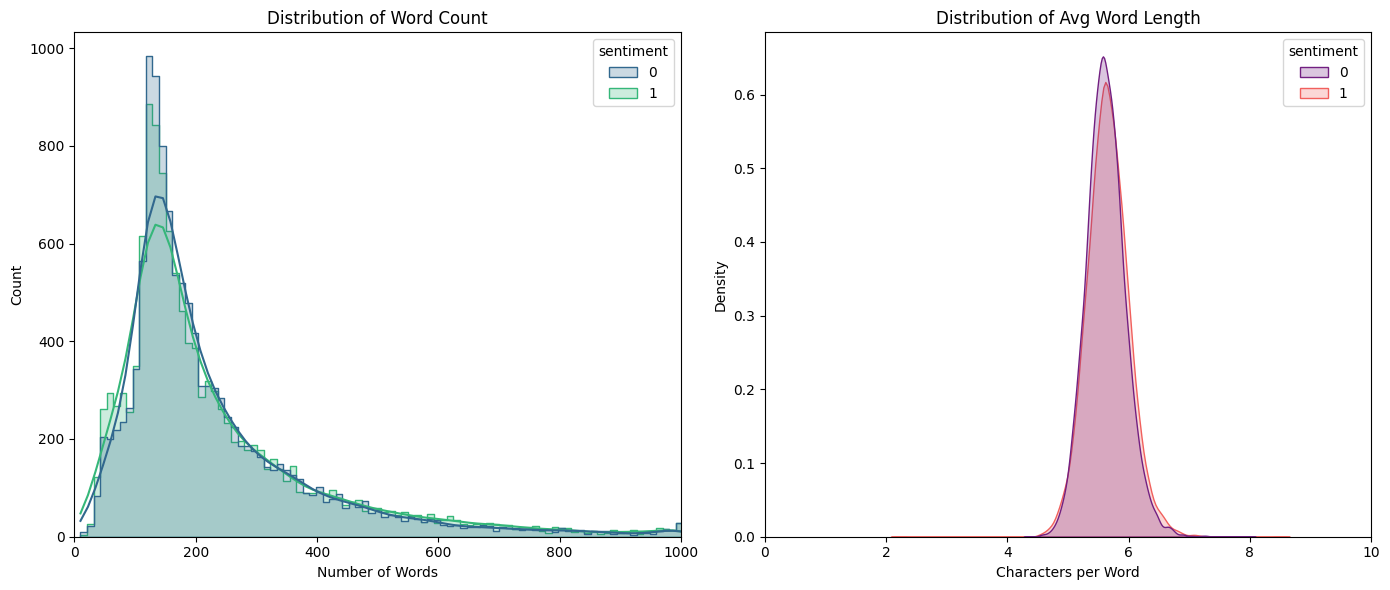

In [ ]:
plt.figure(figsize=(14, 6))

# Plot Word Count Distribution
plt.subplot(1, 2, 1)
sns.histplot(data=train_df, x='word_count', hue='sentiment', kde=True, element="step", palette='viridis')
plt.title('Distribution of Word Count')
plt.xlabel('Number of Words')
plt.xlim(0, 1000) 

# Plot Average Word Length Distribution
plt.subplot(1, 2, 2)
sns.kdeplot(data=train_df, x='avg_word_length', hue='sentiment', fill=True, palette='magma')
plt.title('Distribution of Avg Word Length')
plt.xlabel('Characters per Word')
plt.xlim(0, 10)

plt.tight_layout()
plt.show()

In [ ]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(train_df['cleaned_text'])
features = tfidf.get_feature_names_out()

# 3. Global Importance
global_mean_tfidf = tfidf_matrix.mean(axis=0).tolist()[0]
global_importance = pd.DataFrame({'word': features, 'score': global_mean_tfidf})
global_importance = global_importance.sort_values(by='score', ascending=False)

print("Top 10 Global Important Words:")
print(global_importance.head(10))

Top 10 Global Important Words:
        word     score
2918   movie  0.057172
1604    film  0.048786
2566    like  0.027950
2387    just  0.026368
1862    good  0.024650
3576  really  0.021004
4228   story  0.020975
4508    time  0.020442
286      bad  0.019224
1910   great  0.018387


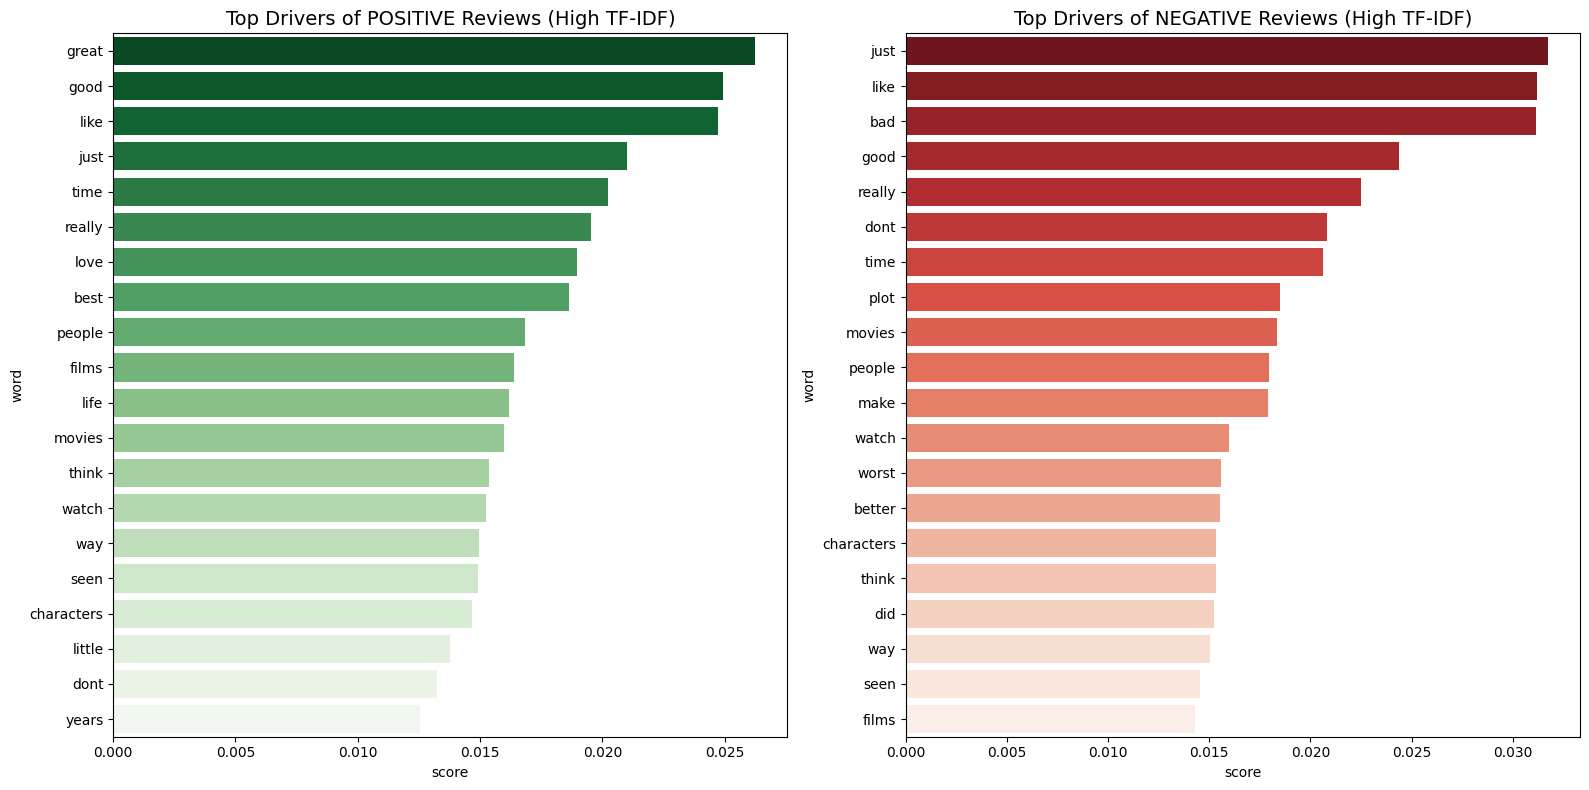

In [ ]:
def get_top_features_by_class(matrix, labels, features, target_label, top_n=25):
    # 1. Convert Pandas Series to a raw Boolean array for indexing
    row_indices = (labels == target_label).values

    # 2. Filter the sparse matrix rows
    subset_matrix = matrix[row_indices]

    # 3. Calculate mean. This returns a 2D matrix: [[val1, val2, ...]]
    mean_matrix = subset_matrix.mean(axis=0)

    # 4. Convert to a standard 1D numpy array
    # np.asarray() makes it an array, .flatten() makes it 1D
    mean_weights = np.asarray(mean_matrix).flatten()

    # 5. Create DataFrame and sort
    df = pd.DataFrame({'word': features, 'score': mean_weights})

    return df.sort_values(by='score', ascending=False).head(top_n)
# 1. Get top words for both classes
top_pos = get_top_features_by_class(tfidf_matrix, train_df['sentiment'], features, 1)
top_neg = get_top_features_by_class(tfidf_matrix, train_df['sentiment'], features, 0)

# Ignoring commmon words

ignore_list = ['movie', 'film', 'story', 'character', 'acting', 'director', 'scene']

top_pos_filtered = top_pos[~top_pos['word'].isin(ignore_list)].head(20)
top_neg_filtered = top_neg[~top_neg['word'].isin(ignore_list)].head(20)


# 2. Plotting the Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Positive Chart (Green)
sns.barplot(data=top_pos_filtered, x='score', y='word', ax=ax1, hue='word', palette='Greens_r', legend=False)
ax1.set_title('Top Drivers of POSITIVE Reviews (High TF-IDF)', fontsize=14)

# Negative Chart (Red)
sns.barplot(data=top_neg_filtered, x='score', y='word', ax=ax2, hue='word', palette='Reds_r', legend=False)
ax2.set_title('Top Drivers of NEGATIVE Reviews (High TF-IDF)', fontsize=14)

plt.tight_layout()
plt.show()

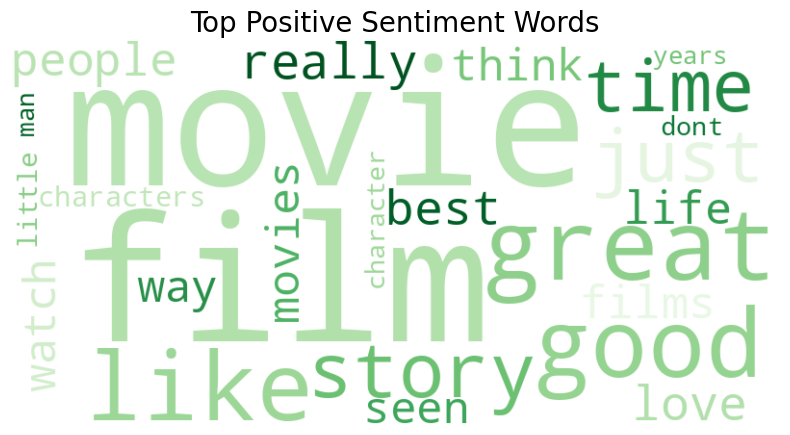

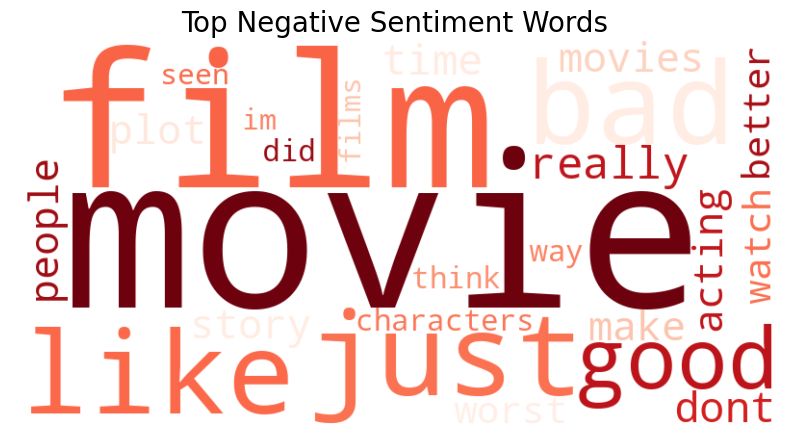

In [12]:
def plot_tfidf_wordcloud(tfidf_df, title, color):
    # Convert our TF-IDF dataframe into a dictionary {word: score}
    word_freq = dict(zip(tfidf_df['word'], tfidf_df['score']))

    wc = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap=color,
                   max_words=100).generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()

# Use the top_pos and top_neg dataframes we created in Phase 4
plot_tfidf_wordcloud(top_pos, "Top Positive Sentiment Words", "Greens")
plot_tfidf_wordcloud(top_neg, "Top Negative Sentiment Words", "Reds")

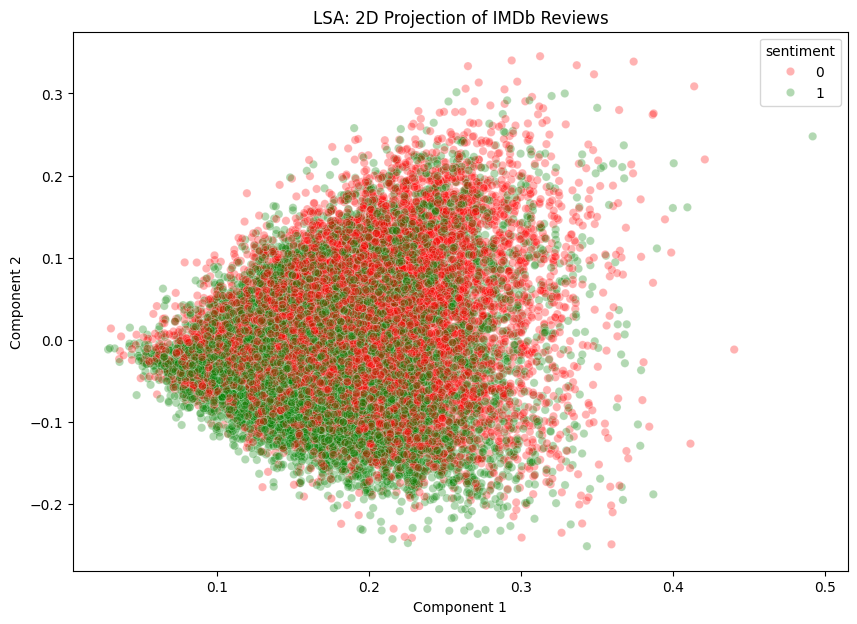

In [15]:
svd = TruncatedSVD(n_components=2, random_state=42)
lsa_matrix = svd.fit_transform(tfidf_matrix)

# 2. Create a DataFrame for plotting
lsa_df = pd.DataFrame(lsa_matrix, columns=['Component 1', 'Component 2'])
lsa_df['sentiment'] = train_df['sentiment'].values

# 3. Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=lsa_df,
    x='Component 1', y='Component 2',
    hue='sentiment',
    alpha=0.3,
    palette={1: 'green', 0: 'red'}
)
plt.title("LSA: 2D Projection of IMDb Reviews")
plt.show()

new features uksigmak

In [ ]:
pos_mask = (train_df['sentiment'] == 1).values
pos_mean = np.asarray(tfidf_matrix[pos_mask].mean(axis=0)).flatten()

# 2. Calculate the mean TF-IDF for Negative reviews
neg_mask = (train_df['sentiment'] == 0).values
neg_mean = np.asarray(tfidf_matrix[neg_mask].mean(axis=0)).flatten()

# 3. Combine into a single Comparison DataFrame
comparison = pd.DataFrame({
    'word': features,
    'pos_score': pos_mean,
    'neg_score': neg_mean
})

# 4. Calculate the Difference (The "Polarity Score")
comparison['diff'] = comparison['pos_score'] - comparison['neg_score']

# 5. Look at the most polarized words
print("Words with the highest POSITIVE pull:")
print(comparison.sort_values(by='diff', ascending=False).head(10))

print("\nWords with the highest NEGATIVE pull:")
print(comparison.sort_values(by='diff', ascending=True).head(10))

Words with the highest POSITIVE pull:
           word  pos_score  neg_score      diff
1910      great   0.026256   0.010492  0.015764
2665       love   0.018978   0.008996  0.009982
369        best   0.018624   0.008897  0.009727
1444  excellent   0.010947   0.002376  0.008571
4909  wonderful   0.009445   0.001875  0.007570
2558       life   0.016166   0.009899  0.006267
339   beautiful   0.009165   0.003416  0.005749
2669      loved   0.007992   0.002348  0.005644
3259    perfect   0.007691   0.002092  0.005598
138     amazing   0.007287   0.001715  0.005571

Words with the highest NEGATIVE pull:
          word  pos_score  neg_score      diff
286        bad   0.007327   0.031159 -0.023831
4934     worst   0.001249   0.015563 -0.014314
2918     movie   0.050077   0.064290 -0.014213
2387      just   0.021024   0.031730 -0.010706
4805     waste   0.000602   0.010649 -0.010047
278      awful   0.000948   0.010363 -0.009415
3337      plot   0.009922   0.018475 -0.008554
4428  terrible   0.

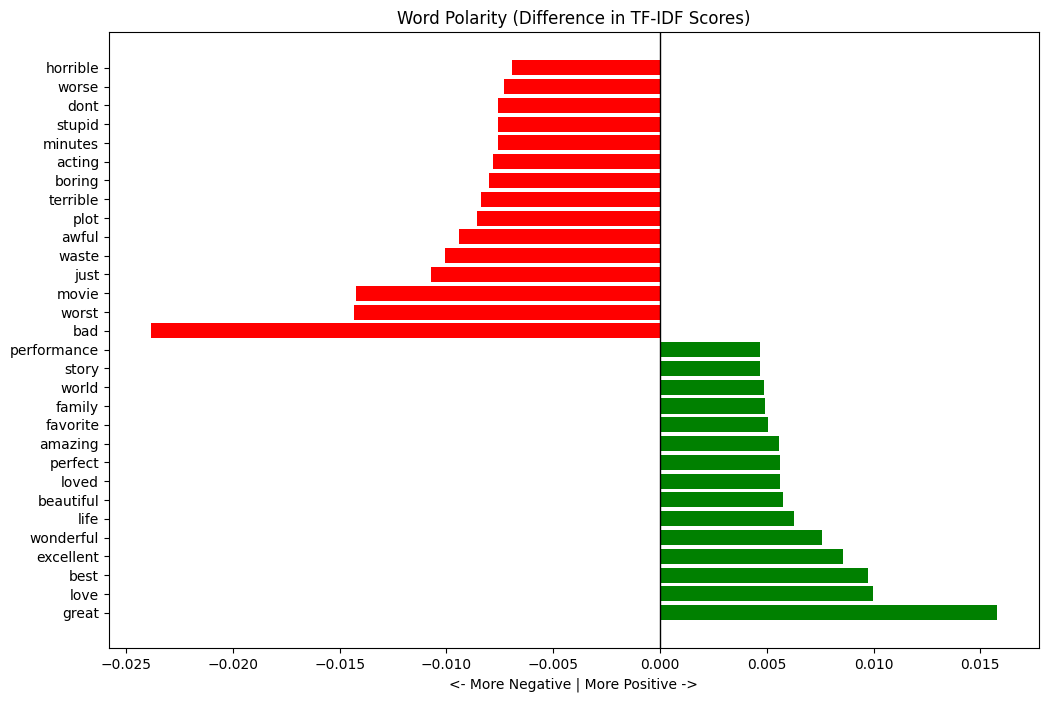

In [ ]:
polarized_words = pd.concat([
    comparison.sort_values(by='diff', ascending=False).head(15),
    comparison.sort_values(by='diff', ascending=True).head(15)
])

# Plotting
plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in polarized_words['diff']]
plt.barh(polarized_words['word'], polarized_words['diff'], color=colors)
plt.title("Word Polarity (Difference in TF-IDF Scores)")
plt.xlabel("<- More Negative | More Positive ->")
plt.axvline(0, color='black', lw=1) 
plt.show()

In [ ]:
X = train_df['text']
y = train_df['sentiment']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define our 3 candidate models
models = {
    "Naive Bayes": Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)),
        ('clf', MultinomialNB())
    ]),

    "Logistic Regression": Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2))),
        ('clf', LogisticRegression(max_iter=1000, C=1.0))
    ]),

    "Linear SVM (Soft Margin)": Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2))),
        ('clf', LinearSVC(C=0.5, dual=False)) # C=0.5 makes it a 'softer' margin
    ])
}

# 3. Train and Evaluate each model
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_val)

    # Store and print results
    acc = accuracy_score(y_val, y_pred)
    results[name] = acc

    print(f"\nResults for {name}:")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_val, y_pred, target_names=['Negative', 'Positive']))
    print("-" * 50)

# 4. Final Comparison
print("\n--- Final Accuracy Comparison ---")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

Training Naive Bayes...

Results for Naive Bayes:
Accuracy: 0.8542
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      2518
    Positive       0.85      0.85      0.85      2463

    accuracy                           0.85      4981
   macro avg       0.85      0.85      0.85      4981
weighted avg       0.85      0.85      0.85      4981

--------------------------------------------------
Training Logistic Regression...

Results for Logistic Regression:
Accuracy: 0.8785
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      2518
    Positive       0.87      0.89      0.88      2463

    accuracy                           0.88      4981
   macro avg       0.88      0.88      0.88      4981
weighted avg       0.88      0.88      0.88      4981

--------------------------------------------------
Training Linear SVM (Soft Margin)...

Results for Linear SVM (Soft Margin):
Accuracy: 0.8737
 

In [19]:
X_test = test_df["text"]
y_test = test_df["sentiment"]
for name, model in models.items():
  y = model.predict(X_test)
  acc = accuracy_score(y , y_test)
  print(f"Test accuracy of {name}: {acc}")

Test accuracy of Naive Bayes: 0.83964
Test accuracy of Logistic Regression: 0.87544
Test accuracy of Linear SVM (Soft Margin): 0.8702


In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('svm', LinearSVC(dual=False, max_iter=2000))
])

# 2. Define the Parameter Grid
param_grid = {
    'svm__C': [0.01, 0.1, 1, 10],
    'tfidf__max_features': [5000, 10000],
    'tfidf__ngram_range': [(1, 1), (1, 2)]
}

# 3. Setup Grid Search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=1)

# 4. Run the Search
print("Starting Grid Search... this may take a few minutes.")
grid_search.fit(X_train, y_train)

# 5. Results
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# 6. Evaluate the Best Model on the Test Set
best_model = grid_search.best_estimator_
test_preds = best_model.predict(X_val)
print(f"Final Validation Accuracy: {accuracy_score(y_val, test_preds):.4f}")

Starting Grid Search... this may take a few minutes.
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters: {'svm__C': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best Cross-Validation Accuracy: 0.8846
Final Validation Accuracy: 0.8826


In [ ]:
# 1. Pipeline
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('nb', MultinomialNB())
])

# 2. Parameter Grid
nb_param_grid = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'nb__alpha': [0.01, 0.1, 0.5, 1.0, 10.0]
}

# 3. Grid Search
nb_grid = GridSearchCV(nb_pipeline, nb_param_grid, cv=5, n_jobs=-1, verbose=1)
nb_grid.fit(X_train, y_train)

print(f"Best NB Params: {nb_grid.best_params_}")
print(f"Best NB CV Score: {nb_grid.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best NB Params: {'nb__alpha': 1.0, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}
Best NB CV Score: 0.8686


In [ ]:
# 1. Pipeline
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('lr', LogisticRegression(max_iter=1000, solver='liblinear')) 
])

# 2. Parameter Grid
lr_param_grid = {
    'tfidf__max_features': [5000, 10000],
    'tfidf__ngram_range': [(1, 2)], # We know bigrams usually help LogReg
    'lr__C': [0.1, 1, 10],
    'lr__penalty': ['l1', 'l2']
}

# 3. Grid Search
lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=5, n_jobs=-1, verbose=1)
lr_grid.fit(X_train, y_train)

print(f"Best LogReg Params: {lr_grid.best_params_}")
print(f"Best LogReg CV Score: {lr_grid.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best LogReg Params: {'lr__C': 1, 'lr__penalty': 'l2', 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best LogReg CV Score: 0.8846


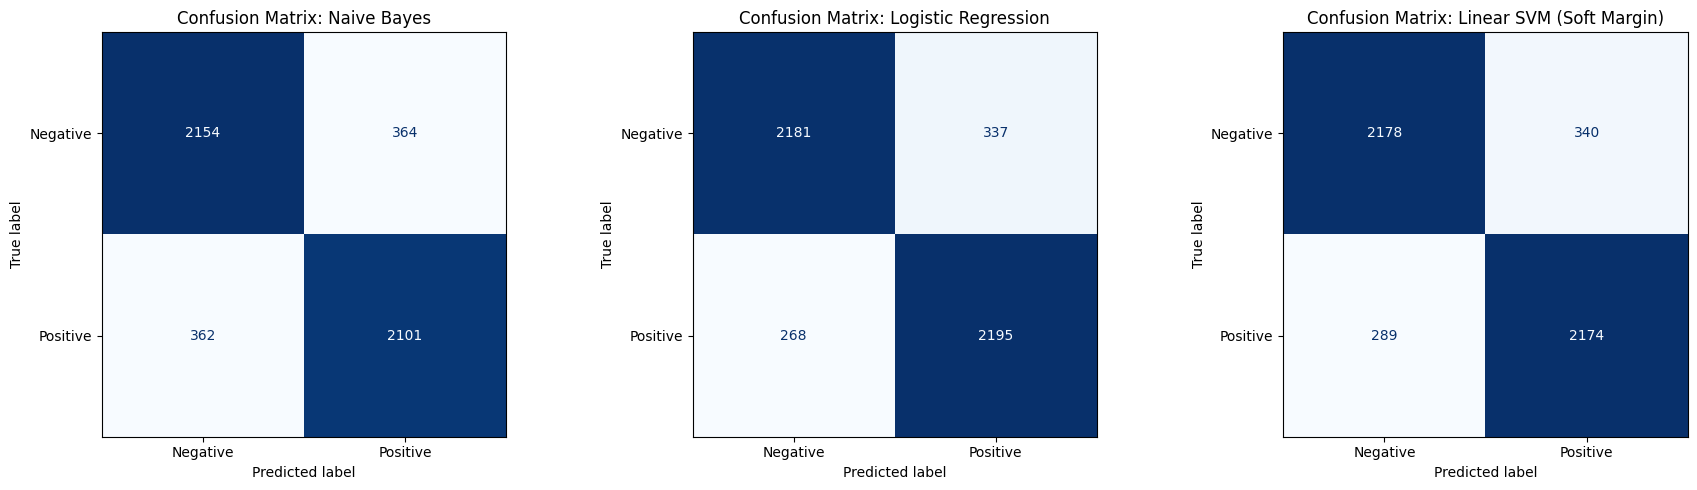

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    # 1. Get predictions for the validation set
    y_pred = model.predict(X_val)

    # 2. Generate the confusion matrix
    cm = confusion_matrix(y_val, y_pred)

    # 3. Plot using ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Confusion Matrix: {name}")

plt.tight_layout()
plt.show()

In [21]:
MAX_VOCAB_SIZE = 10000
MAX_LENGTH = 250
BATCH_SIZE = 128
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def tokenize(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

# 1. Build Vocabulary
all_words = []
for text in X_train:
    all_words.extend(tokenize(text))

counts = Counter(all_words)
vocab = {word: i+2 for i, (word, _) in enumerate(counts.most_common(MAX_VOCAB_SIZE-2))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

# 2. Convert text to integers
def text_to_ints(text):
    tokens = tokenize(text)
    return [vocab.get(token, 1) for token in tokens][:MAX_LENGTH]

def pad_sequence(seq):
    return seq + [0] * (MAX_LENGTH - len(seq))

class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.data = [torch.tensor(pad_sequence(text_to_ints(t))) for t in texts]
        self.labels = torch.tensor(labels.values, dtype=torch.float32)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.data[idx], self.labels[idx]

train_loader = DataLoader(IMDBDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(IMDBDataset(X_val, y_val), batch_size=BATCH_SIZE)

In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)


        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        x = self.embedding(x) # [batch_size, seq_len, embed_dim]

        out, hidden = self.rnn(x)

        h_n = hidden[0]

        # h_n shape is [num_layers, batch_size, hidden_dim]
        return self.sigmoid(self.fc(h_n[-1])).squeeze()
    
class SentimentRNN(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(SentimentRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # We use a SimpleRNN but with better initialization
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)

        # Apply Orthogonal Initialization to RNN weights
        for name, param in self.rnn.named_parameters():
            if 'weight' in name:
                nn.init.orthogonal_(param)

        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    embedded = self.embedding(x)

    # out shape: [batch_size, seq_len, hidden_dim]
    out, _ = self.rnn(embedded)

    #Global Max Pool
    out = torch.max(out, dim=1)[0]

    return self.sigmoid(self.fc(out)).squeeze()

In [23]:
def train(model, train_loader, val_loader, epochs=10 , lr = 0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    model.to(DEVICE)

    # Dictionary to store metrics
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_train_loss = 0.0
        for texts, labels in train_loader:
            texts, labels = texts.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(texts)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss / len(train_loader)

        # --- VALIDATION PHASE ---
        model.eval()
        running_val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(DEVICE), labels.to(DEVICE)
                outputs = model(texts)

                v_loss = criterion(outputs, labels)
                running_val_loss += v_loss.item()

                correct += ((outputs > 0.5) == labels).sum().item()

        avg_val_loss = running_val_loss / len(val_loader)
        acc = correct / len(val_loader.dataset)

        # Save metrics
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(acc)

        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {acc:.4f}")

    return history

In [24]:
rnn = SentimentRNN(MAX_VOCAB_SIZE, 64, 64)
lstm = SentimentLSTM(MAX_VOCAB_SIZE, 64, 64)

In [25]:
print("Training RNN...")
rnn_history = train(rnn, train_loader, val_loader)

print("\nTraining LSTM...")
lstm_history = train(lstm, train_loader, val_loader)

Training RNN...
Epoch 1: Train Loss: 0.5982 | Val Loss: 0.5118 | Val Acc: 0.7511
Epoch 2: Train Loss: 0.4311 | Val Loss: 0.4452 | Val Acc: 0.7964
Epoch 3: Train Loss: 0.3632 | Val Loss: 0.4489 | Val Acc: 0.7946
Epoch 4: Train Loss: 0.3138 | Val Loss: 0.4391 | Val Acc: 0.8111
Epoch 5: Train Loss: 0.2804 | Val Loss: 0.4349 | Val Acc: 0.8187
Epoch 6: Train Loss: 0.2378 | Val Loss: 0.4549 | Val Acc: 0.8139
Epoch 7: Train Loss: 0.2108 | Val Loss: 0.4689 | Val Acc: 0.8161
Epoch 8: Train Loss: 0.1876 | Val Loss: 0.4869 | Val Acc: 0.8183
Epoch 9: Train Loss: 0.1657 | Val Loss: 0.5202 | Val Acc: 0.8169
Epoch 10: Train Loss: 0.1498 | Val Loss: 0.5230 | Val Acc: 0.8143

Training LSTM...
Epoch 1: Train Loss: 0.6942 | Val Loss: 0.6937 | Val Acc: 0.4955
Epoch 2: Train Loss: 0.6844 | Val Loss: 0.7006 | Val Acc: 0.5091
Epoch 3: Train Loss: 0.5890 | Val Loss: 0.6394 | Val Acc: 0.6585
Epoch 4: Train Loss: 0.5068 | Val Loss: 0.6118 | Val Acc: 0.7242
Epoch 5: Train Loss: 0.4289 | Val Loss: 0.6084 | Val Ac

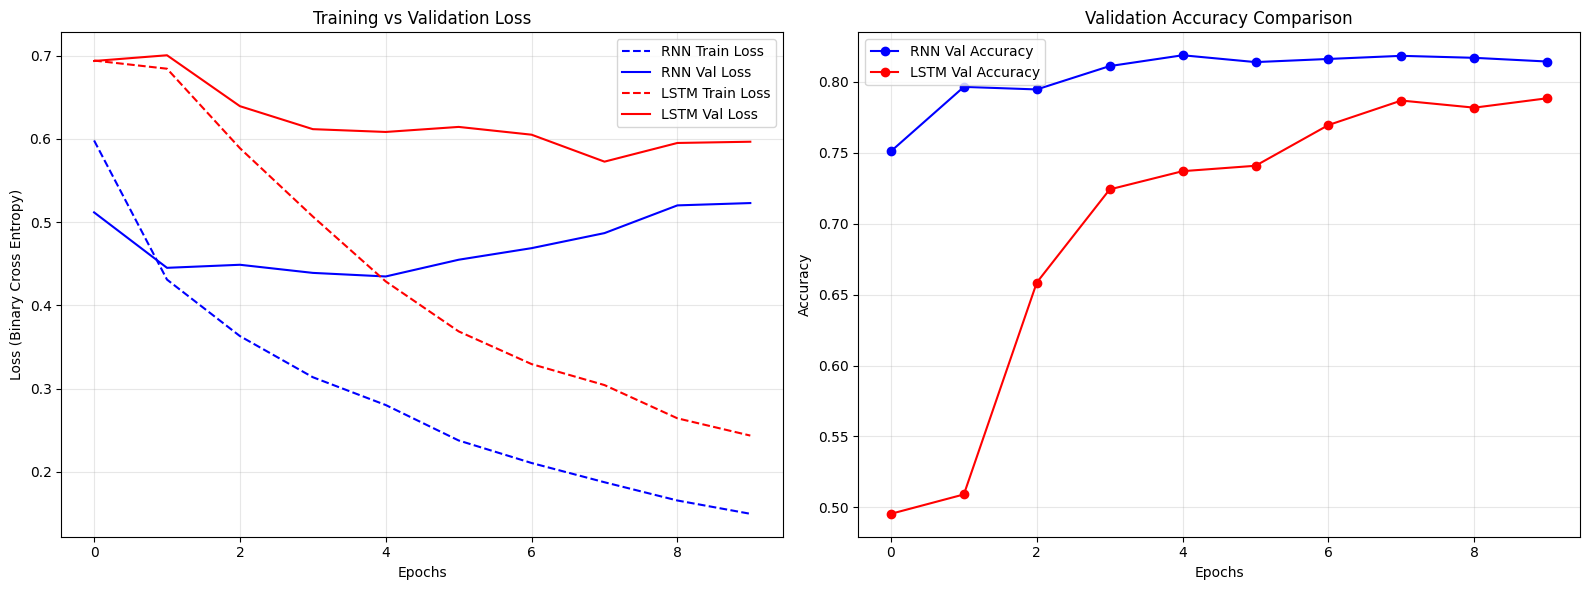

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Loss Curves ---
ax1.plot(rnn_history['train_loss'], label='RNN Train Loss', color='blue', linestyle='--')
ax1.plot(rnn_history['val_loss'], label='RNN Val Loss', color='blue')
ax1.plot(lstm_history['train_loss'], label='LSTM Train Loss', color='red', linestyle='--')
ax1.plot(lstm_history['val_loss'], label='LSTM Val Loss', color='red')

ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (Binary Cross Entropy)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Accuracy Curves ---
ax2.plot(rnn_history['val_acc'], label='RNN Val Accuracy', color='blue', marker='o')
ax2.plot(lstm_history['val_acc'], label='LSTM Val Accuracy', color='red', marker='o')

ax2.set_title('Validation Accuracy Comparison')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
test_loader = DataLoader(IMDBDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=True)


total_correct_rnn = 0
total_correct_lstm = 0
length = 0

for i, batch in enumerate(test_loader):
  texts , labels = batch
  texts, labels = texts.to(DEVICE), labels.to(DEVICE)
  length += len(labels)

  outputs_rnn = rnn(texts)
  outputs_lstm = lstm(texts)

  correct_rnn = ((outputs_rnn > 0.5) == labels).sum().item()
  correct_lstm = ((outputs_lstm > 0.5) == labels).sum().item()

  total_correct_rnn += correct_rnn
  total_correct_lstm += correct_lstm

avg_rnn_acc = total_correct_rnn/length
avg_lstm_acc = total_correct_lstm/length

print(f"Test accuracy of RNN: {avg_rnn_acc}")
print(f"Test accuracy of LSTM: {avg_lstm_acc}")

Test accuracy of RNN: 0.80244
Test accuracy of LSTM: 0.7808


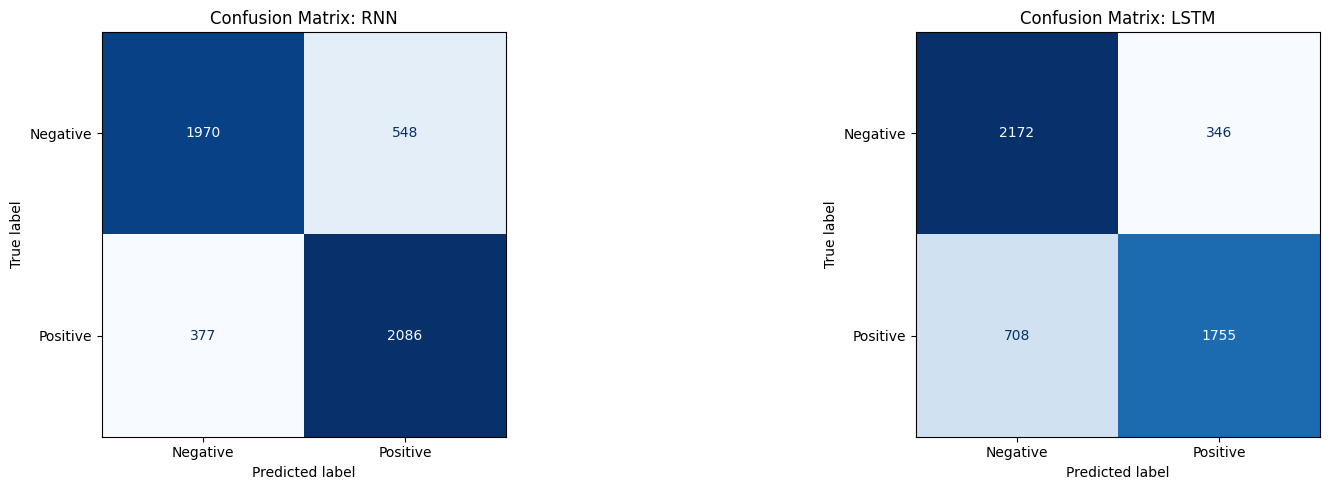

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

y_val = []
y_rnn = []
y_lstm = []

for i, batch in enumerate(val_loader):
  texts , labels = batch
  texts, labels = texts.to(DEVICE), labels.to(DEVICE)

  outputs_rnn = rnn(texts)
  outputs_lstm = lstm(texts)

  rnn_pred = (outputs_rnn > 0.5).int().tolist()
  lstm_pred = (outputs_lstm > 0.5).int().tolist()

  y_rnn += rnn_pred
  y_lstm += lstm_pred
  y_val += labels.tolist()

# 2. Generate the confusion matrix
cm = confusion_matrix(y_val, y_rnn)

# 3. Plot using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f"Confusion Matrix: RNN")


# 2. Generate the confusion matrix
cm = confusion_matrix(y_val, y_lstm)

# 3. Plot using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(f"Confusion Matrix: LSTM")

plt.tight_layout()
plt.show()